In [1]:
!pip install -q scikit-learn==1.3.2 imbalanced-learn==0.11.0 xgboost==2.1.1 h5py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.8.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
cuml-cu12 25.10.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but y

In [2]:
!pip uninstall -y scikit-learn imbalanced-learn

Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: imbalanced-learn 0.11.0
Uninstalling imbalanced-learn-0.11.0:
  Successfully uninstalled imbalanced-learn-0.11.0


In [4]:
!pip install -q scikit-learn==1.3.2 imbalanced-learn==0.11.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
esda 2.8.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
cuml-cu12 25.10.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
mapclassify 2.10.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.


In [1]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler

print("ADASYN OK")

ADASYN OK


In [2]:
# Cell 1: Install libraries and mount Drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Cell 2: Imports
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc

from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler

In [6]:
# Cell 3: Paths and output directory
paths = {
    "train": "/content/drive/My Drive/Cybersecurity/Cyber_All_Codes/Embedding_Concatenate/Concatenated_Train_embeddings.csv",
    "val":   "/content/drive/My Drive/Cybersecurity/Cyber_All_Codes/Embedding_Concatenate/Concatenated_Val_embeddings.csv",
    "test":  "/content/drive/My Drive/Cybersecurity/Cyber_All_Codes/Embedding_Concatenate/Concatenated_Test_embeddings.csv"
}

output_dir = "/content/drive/My Drive/Cybersecurity/Ensemble model training/100k_ADASYN_4class_XGBoost"
os.makedirs(output_dir, exist_ok=True)

print("Output dir:", output_dir)
print("Train file exists:", os.path.exists(paths["train"]))
print("Val file exists:", os.path.exists(paths["val"]))
print("Test file exists:", os.path.exists(paths["test"]))

Output dir: /content/drive/My Drive/Cybersecurity/Ensemble model training/100k_ADASYN_4class_XGBoost
Train file exists: True
Val file exists: True
Test file exists: True


In [7]:
# Cell 4: Load CSVs and ensure 'Label' exists
train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

for df,name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    if "Label" not in df.columns:
        raise ValueError(f"'Label' column not found in {name} CSV. Columns: {df.columns.tolist()}")

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
print("Train label unique count sample:", np.unique(train_df["Label"]))

Shapes: (586532, 385) (195448, 385) (195519, 385)
Train label unique count sample: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 22]


In [8]:
# Cell 5: Remap to 4 classes if needed (0=BENIGN,1=DDoS,2=ZeroDay,3=Malware)
def remap_to_4(series):
    return series.apply(
        lambda x: 0 if x == 0 else (1 if x in [1,2,3,4] else (2 if 5 <= x <= 18 else 3))
    )

# apply remap only if labels larger than 3 are present
if train_df["Label"].max() > 3 or val_df["Label"].max() > 3 or test_df["Label"].max() > 3:
    print("Detected labels > 3, remapping to 4-class.")
    train_df["Label"] = remap_to_4(train_df["Label"])
    val_df["Label"]   = remap_to_4(val_df["Label"])
    test_df["Label"]  = remap_to_4(test_df["Label"])
else:
    print("Labels already in 4-class space (0..3).")

print("Train class distribution (before resample):", np.bincount(train_df["Label"]))

Detected labels > 3, remapping to 4-class.
Train class distribution (before resample): [ 77336 170147 333922   5127]


In [9]:
# Cell 6: Split X/y and scale
X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val = val_df["Label"].values.astype(int)

X_test = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test = test_df["Label"].values.astype(int)

print("Shapes: X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Save scaler if needed
import joblib
joblib.dump(scaler, os.path.join(output_dir, "scaler.save"))
print("Scaler saved.")

Shapes: X_train (586532, 384) X_val (195448, 384) X_test (195519, 384)
Scaler saved.


In [10]:
# Correct balancing: Undersample majority, ADASYN on Malware and Benign

from collections import Counter
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN

# ============================================================
# 1) UNDERSAMPLE MAJORITY CLASSES (1 = DDoS, 2 = Zero-Day)
# ============================================================
rus = RandomUnderSampler(
    sampling_strategy={
        1: 100000,   # DDoS
        2: 100000    # ZeroDay
    },
    random_state=42
)

X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print("After undersampling:", Counter(y_rus))

# ---------------------------------
# 2) SMOTE for Benign (class 0)
# ---------------------------------
smote = SMOTE(
    sampling_strategy={0: 100000},
    random_state=42,
    k_neighbors=5
)

X_sm, y_sm = smote.fit_resample(X_rus, y_rus)
print("After SMOTE (Benign):", Counter(y_sm))


# ============================================================
# 2) APPLY ADASYN ONLY TO MINORITY CLASS (3 = Malware)
# ============================================================
adasyn = ADASYN(
    sampling_strategy={3: 100000},  # Malware from 5k → 1 lac
    random_state=42,
    n_neighbors=3
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_sm, y_sm)
print("After ADASYN minority class:", Counter(y_train_bal))

After undersampling: Counter({1: 100000, 2: 100000, 0: 77336, 3: 5127})
After SMOTE (Benign): Counter({0: 100000, 1: 100000, 2: 100000, 3: 5127})
After ADASYN minority class: Counter({3: 100362, 0: 100000, 1: 100000, 2: 100000})


In [11]:
import gc

del X_train_scaled, X_rus, X_sm
del y_train, y_rus, y_sm
gc.collect()

0

In [ ]:
# Cell 8: Save balanced train CSV (features + Label) to Colab SSD

output_dir = "/content"  # <-- Colab SSD root

balanced_df = pd.DataFrame(X_train_bal, columns=[f"f{i}" for i in range(X_train_bal.shape[1])])
balanced_df["Label"] = y_train_bal

balanced_csv_path = os.path.join(output_dir, "Train_balanced_4class.csv")
balanced_df.to_csv(balanced_csv_path, index=False)

print("Saved balanced training CSV to:", balanced_csv_path)

Saved balanced training CSV to: /content/Train_balanced_4class.csv


In [12]:
# Cell 9: Prepare DMatrix for XGBoost
# Use the balanced training arrays; val/test use scaled versions (original distributions)

dtrain = xgb.DMatrix(X_train_bal, label=y_train_bal)
dval   = xgb.DMatrix(X_val_scaled, label=y_val)
dtest  = xgb.DMatrix(X_test_scaled, label=y_test)

classes = np.array([0, 1, 2, 3])
n_classes = len(classes)
print("Number of classes:", n_classes)

Number of classes: 4


In [13]:
# Cell 10: Train XGBoost with early stopping

output_dir = "/content/drive/My Drive/Cybersecurity/Ensemble model training/100k_ADASYN_4class_XGBoost"

params = {
    "objective": "multi:softprob",
    "num_class": n_classes,
    "tree_method": "hist",
    "device": "cuda",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "mlogloss"
}

evals = [(dtrain, "train"), (dval, "validation")]

start_time = time.time()
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=evals,
    callbacks=[xgb.callback.EarlyStopping(rounds=40, metric_name="mlogloss")]
)

training_time = time.time() - start_time
print("Training finished in {:.2f} seconds".format(training_time))

# Save model
model_json = os.path.join(output_dir, "xgboost_4class_ADASYN_balanced.json")
bst.save_model(model_json)

# Save HDF5 wrapper
import h5py
with open(model_json, "rb") as f:
    model_bytes = f.read()

h5_path = os.path.join(output_dir, "xgboost_4class_ADASYN_balanced.h5")
with h5py.File(h5_path, "w") as h5f:
    h5f.create_dataset("xgboost_json", data=np.void(model_bytes))
    h5f.attrs["num_classes"] = n_classes

print("Model saved to:", model_json)
print("HDF5 wrapper saved to:", h5_path)

[0]	train-mlogloss:1.33199	validation-mlogloss:1.33452
[1]	train-mlogloss:1.28251	validation-mlogloss:1.28676
[2]	train-mlogloss:1.23720	validation-mlogloss:1.24263
[3]	train-mlogloss:1.19551	validation-mlogloss:1.20168
[4]	train-mlogloss:1.15700	validation-mlogloss:1.16360
[5]	train-mlogloss:1.12135	validation-mlogloss:1.12813
[6]	train-mlogloss:1.08826	validation-mlogloss:1.09511
[7]	train-mlogloss:1.05742	validation-mlogloss:1.06412
[8]	train-mlogloss:1.02866	validation-mlogloss:1.03508
[9]	train-mlogloss:1.00177	validation-mlogloss:1.00781
[10]	train-mlogloss:0.97659	validation-mlogloss:0.98217
[11]	train-mlogloss:0.95299	validation-mlogloss:0.95805
[12]	train-mlogloss:0.93087	validation-mlogloss:0.93531
[13]	train-mlogloss:0.91004	validation-mlogloss:0.91387
[14]	train-mlogloss:0.89044	validation-mlogloss:0.89365
[15]	train-mlogloss:0.87199	validation-mlogloss:0.87455
[16]	train-mlogloss:0.85459	validation-mlogloss:0.85652
[17]	train-mlogloss:0.83817	validation-mlogloss:0.83940
[1

In [14]:
# Cell 12: Evaluation — Accuracy + Macro F1 + Classification Reports

def evaluate_and_report(name, X, y_true):
    d = xgb.DMatrix(X)
    proba = bst.predict(d)
    y_pred = proba.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    return y_pred, proba


# --- Evaluate on TRAIN (balanced) ---
y_train_pred, train_proba = evaluate_and_report(
    "TRAIN (balanced)",
    X_train_bal,
    y_train_bal
)

# --- Evaluate on VALIDATION (original distribution) ---
y_val_pred, val_proba = evaluate_and_report(
    "VALIDATION",
    X_val_scaled,
    y_val
)

# --- Evaluate on TEST (original distribution) ---
y_test_pred, test_proba = evaluate_and_report(
    "TEST",
    X_test_scaled,
    y_test
)


=== TRAIN (balanced) ===
Accuracy: 0.7522492144609129
Macro F1: 0.6545987360404716

Classification Report:
              precision    recall  f1-score   support

           0     0.9572    0.0085    0.0169    100000
           1     0.6314    0.9997    0.7740    100000
           2     0.7207    0.9999    0.8377    100000
           3     0.9800    1.0000    0.9899    100362

    accuracy                         0.7522    400362
   macro avg     0.8223    0.7520    0.6546    400362
weighted avg     0.8225    0.7522    0.6549    400362


=== VALIDATION ===
Accuracy: 0.8675504482010561
Macro F1: 0.6695413782945943

Classification Report:
              precision    recall  f1-score   support

           0     0.1626    0.0013    0.0025     25748
           1     0.7891    0.9984    0.8815     56682
           2     0.9176    0.9997    0.9569    111309
           3     0.7343    0.9737    0.8372      1709

    accuracy                         0.8676    195448
   macro avg     0.6509    0.


===== Confusion Matrix - Train (balanced) =====
[[   850  58360  38746   2044]
 [    33  99966      1      0]
 [     5      0  99994      1]
 [     0      0      0 100362]]


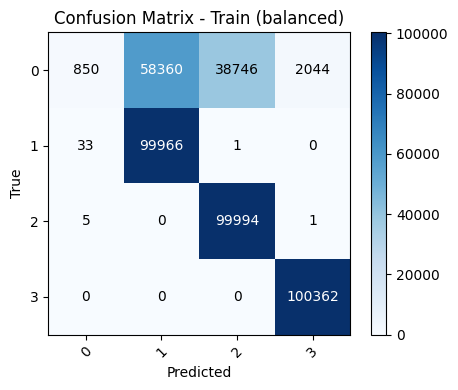


===== Confusion Matrix - Validation =====
[[    33  15120   9995    600]
 [    93  56589      0      0]
 [    32      0 111275      2]
 [    45      0      0   1664]]


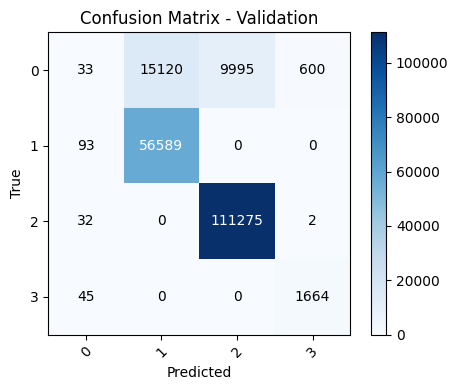


===== Confusion Matrix - Test =====
[[    45  15148   9989    337]
 [    90  56625      0      0]
 [    34      0 111290      0]
 [    33      0      0   1928]]


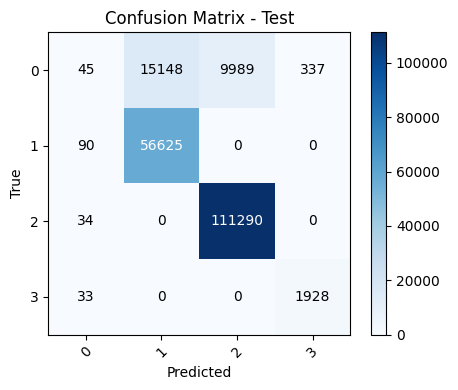

In [15]:
# Cell 13: Confusion matrices and save plots

output_dir = "/content/drive/My Drive/Cybersecurity/Ensemble model training/100k_ADASYN_4class_XGBoost"
def plot_and_save_cm(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred)

    # Print the confusion matrix
    print(f"\n===== {title} =====")
    print(cm)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # Add colorbar
    plt.colorbar()

    # Add class labels on axes
    classes = np.unique(y_true)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add numbers inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

    plt.tight_layout()
    plt.savefig(path)
    plt.show()

plot_and_save_cm(y_train_bal, y_pred=y_train_pred, title="Confusion Matrix - Train (balanced)", path=os.path.join(output_dir, "cm_train.png"))
plot_and_save_cm(y_val, y_val_pred, "Confusion Matrix - Validation", os.path.join(output_dir, "cm_val.png"))
plot_and_save_cm(y_test, y_test_pred, "Confusion Matrix - Test", os.path.join(output_dir, "cm_test.png"))

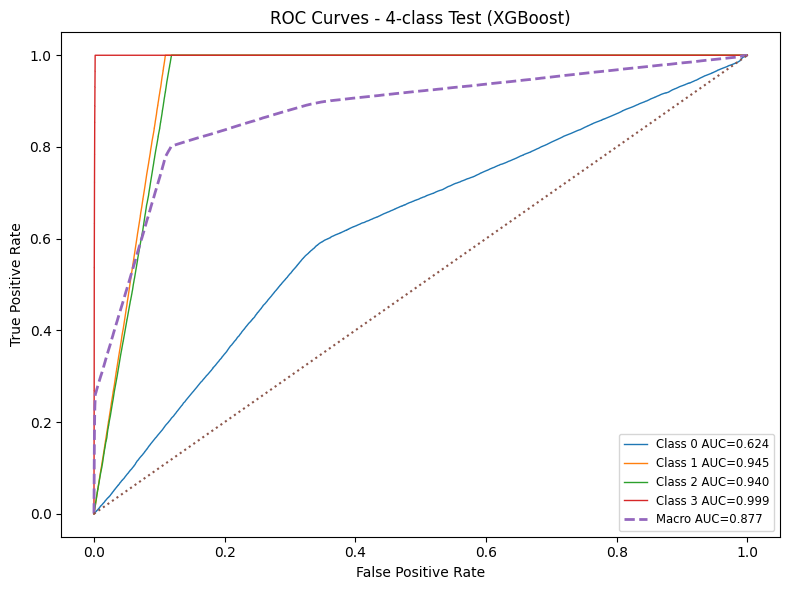

Per-class AUCs: {0: 0.6236007047805211, 1: 0.9451005535778919, 2: 0.9403553263353082, 3: 0.9993569861263948}
Macro AUC: 0.8771049842918964


In [16]:
# Cell 14: ROC curves and AUC (one-vs-rest) for Test
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# macro AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1, label=f"Class {classes[i]} AUC={roc_auc[i]:.3f}")
plt.plot(fpr["macro"], tpr["macro"], '--', linewidth=2, label=f"Macro AUC={roc_auc['macro']:.3f}")
plt.plot([0,1],[0,1], ':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test (XGBoost)")
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_test.png"))
plt.show()

print("Per-class AUCs:", {i:roc_auc[i] for i in range(n_classes)})
print("Macro AUC:", roc_auc["macro"])